In [2]:
from google.colab import drive
drive.mount('/content/drive')

FOLDERNAME = 'ML_Final_Project/walmart-recruiting-store-sales-forecasting'
assert FOLDERNAME is not None, "[!] Enter the foldername."

import sys
sys.path.append('/content/drive/My Drive/{}'.format(FOLDERNAME))

%cd /content/drive/My\ Drive/$FOLDERNAME/

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/My Drive/ML_Final_Project/walmart-recruiting-store-sales-forecasting


In [117]:
import pandas as pd
import numpy as np

df = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')
stores = pd.read_csv('stores.csv')
features = pd.read_csv('features.csv')

def merger(df, stores, features):
    df = df.merge(stores, how='left', on='Store')
    df = df.merge(features, how='left', on=['Store', 'Date', 'IsHoliday'])
    return df

df = merger(df, stores, features)
test = merger(test, stores, features)

df.sort_values('Date', inplace=True)
test.sort_values('Date', inplace=True)

y = df['Weekly_Sales']
X = df.drop(columns=['Weekly_Sales'])
dates = df['Date']

import random
import torch

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# Install

In [5]:
!pip install u8darts[torch] pandas scikit-learn

# Model Implementation

In [169]:
from sklearn.base import BaseEstimator, RegressorMixin
from darts import TimeSeries
from darts.models import TFTModel
from darts.dataprocessing.transformers import Scaler
from darts.utils.likelihood_models import QuantileRegression
import pandas as pd
import numpy as np
import logging

logging.getLogger("pytorch_lightning").setLevel(logging.ERROR)

class TFTRegressor(BaseEstimator, RegressorMixin):
    def __init__(self, input_chunk_length=52, output_chunk_length=4, n_epochs=10, use_gpu=True):
        self.input_chunk_length = input_chunk_length
        self.output_chunk_length = output_chunk_length
        self.n_epochs = n_epochs
        self.use_gpu = use_gpu
        self.model = None
        self.scaler = None
        self.ts_train = None


    def _to_timeseries(self, X, y=None):
        df = X.copy()
        df["Date"] = pd.to_datetime(df["Date"])
        df = df.sort_values("Date")

        if y is not None:
            series_df = pd.DataFrame({"Date": df["Date"], "y": y.values})
            series_df = series_df.groupby("Date").mean().reset_index()
            series_df = series_df.set_index("Date").sort_index()
            return TimeSeries.from_series(series_df["y"], fill_missing_dates=True, freq="W-FRI")
        else:
            df = df.drop_duplicates(subset="Date")
            df = df.set_index("Date").sort_index()
            series = pd.Series(np.zeros(len(df)), index=df.index)
            return TimeSeries.from_series(series, fill_missing_dates=True, freq="W-FRI")


    def fit(self, X, y):
        ts = self._to_timeseries(X, y)
        self.scaler = Scaler()
        ts_scaled = self.scaler.fit_transform(ts)

        self.model = TFTModel(
            input_chunk_length=self.input_chunk_length,
            output_chunk_length=self.output_chunk_length,
            hidden_size=8,
            lstm_layers=1,
            num_attention_heads=2,
            dropout=0.1,
            batch_size=16,
            n_epochs=self.n_epochs,
            likelihood=QuantileRegression([0.1, 0.5, 0.9]),
            force_reset=True,
            add_relative_index=True,
            random_state=SEED,
            pl_trainer_kwargs={
                "accelerator": "gpu" if self.use_gpu else "cpu",
                "devices": 1,
                "logger": False,
                "enable_progress_bar": False,
            }
        )

        self.model.fit(ts_scaled, verbose=False)
        self.ts_train = ts
        return self

    def predict(self, n):
        ts_scaled = self.scaler.transform(self.ts_train)
        pred = self.model.predict(n=n)
        pred = self.scaler.inverse_transform(pred)
        return pred

In [170]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
import pandas as pd

store1_df = df[df["Store"] == 1].copy()
store1_df["Date"] = pd.to_datetime(store1_df["Date"])
store1_df = store1_df.sort_values("Date")
store1_df = store1_df.dropna(subset=["Weekly_Sales"])
store1_df.fillna(method="ffill", inplace=True)

cutoff_date = store1_df["Date"].max() - pd.Timedelta(weeks=4)
train_df = store1_df[store1_df["Date"] <= cutoff_date].copy()
val_df = store1_df[store1_df["Date"] > cutoff_date].copy()

X_train = train_df.drop(columns=["Weekly_Sales"])
y_train = train_df["Weekly_Sales"]

X_val = val_df.drop(columns=["Weekly_Sales"])
y_val = val_df["Weekly_Sales"]
is_holiday = X_val["IsHoliday"].values

model = TFTRegressor(input_chunk_length=52, output_chunk_length=4, n_epochs=10)
model.fit(X_train, y_train)

n = len(X_val)
pred_series = model.predict(n)
y_pred = pred_series.values().flatten()

y_true = y_val.iloc[:len(y_pred)].values
is_holiday = is_holiday[:len(y_pred)]

def weighted_mae(y_true, y_pred, is_holiday):
    weights = np.where(is_holiday, 5, 1)
    return np.sum(weights * np.abs(y_true - y_pred)) / np.sum(weights)

print(f"MAE: {mean_absolute_error(y_true, y_pred):.2f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_true, y_pred)):.2f}")
print(f"WMAE: {weighted_mae(y_true, y_pred, is_holiday):.2f}")

MAE: 20366.52
RMSE: 28377.04
WMAE: 20366.52


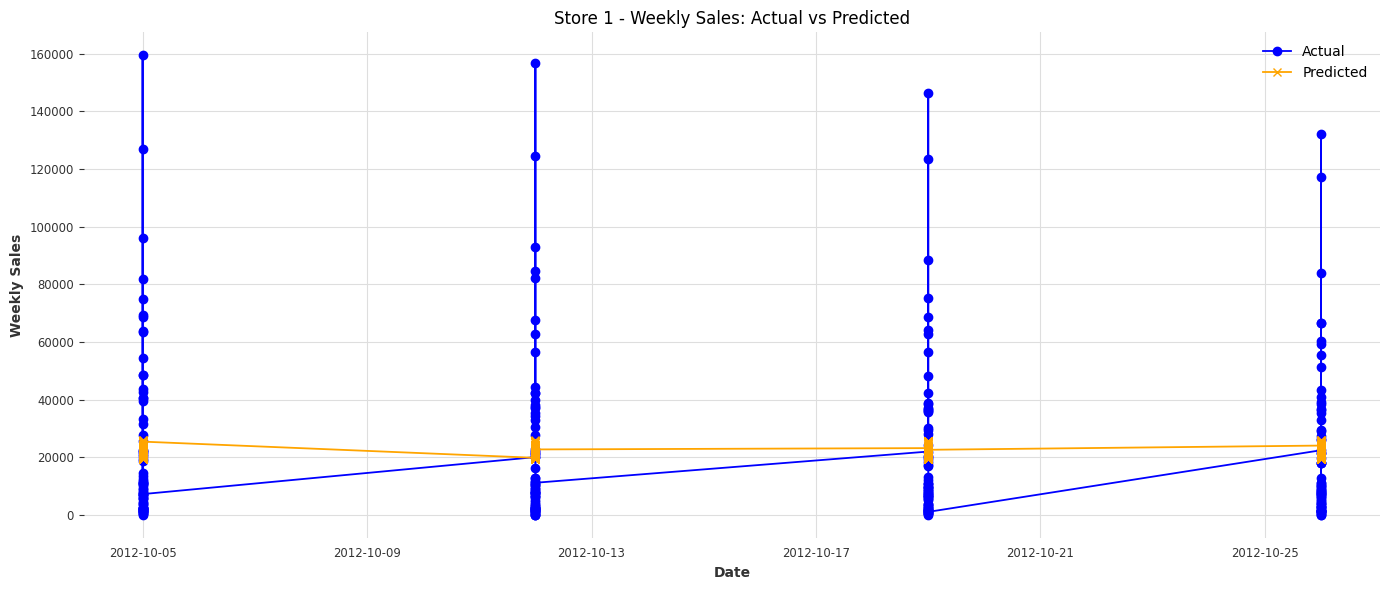

In [171]:
import matplotlib.pyplot as plt

pred_dates = val_df["Date"].iloc[:len(y_pred)]

plt.figure(figsize=(14, 6))
plt.plot(pred_dates, y_true, label='Actual', color='blue', marker='o')
plt.plot(pred_dates, y_pred, label='Predicted', color='orange', marker='x')
plt.title("Store 1 - Weekly Sales: Actual vs Predicted")
plt.xlabel("Date")
plt.ylabel("Weekly Sales")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
